In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from scipy import stats
import re
import nltk
# Uncomment and run the following lines if you haven't downloaded these resources yet
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import os

# Define the path to your Dataset folder in Google Drive
dataset_folder_path = '/content/drive/MyDrive/22CDS0446_NLP/Dataset'

# List all files in the Dataset folder
# Ensure the path is passed as a string
files_in_dataset = os.listdir(dataset_folder_path)

# Filter for CSV files
csv_files = [f for f in files_in_dataset if f.endswith('.csv')]

print(f"Found {len(csv_files)} CSV files in '{dataset_folder_path}':")
for csv_file in csv_files:
    print(f"- {csv_file}")

Found 12 CSV files in '/content/drive/MyDrive/22CDS0446_NLP/Dataset':
- David_Guetta_-_Hey_Mama_Official_Video_ft_Nicki_Minaj_Bebe_Rexha_Afrojack_youtube_comments_english.csv
- David_Guetta_-_Hey_Mama_Official_Video_ft_Nicki_Minaj_Bebe_Rexha_Afrojack_youtube_comments_english (1).csv
- I_Granted_100_Kids_Their_Biggest_Wish_youtube_comments_english.csv
- I_Built_10_Schools_Around_The_World_youtube_comments_english.csv
- Survive_100_Days_Trapped_In_A_Private_Jet_Keep_It_youtube_comments_english.csv
- I_Spent_100_Hours_Inside_The_Pyramids_youtube_comments_english.csv
- 10000_Every_Day_You_Survive_In_The_Wilderness_youtube_comments_english.csv
- 100_Strongest_Vs_100_Smartest_Compete_for_5000000_youtube_comments_english.csv
- 50_YouTubers_Fight_For_1000000_youtube_comments_english.csv
- AMP_EXTREME_OBSTACLE_COURSE_WITH_MRBEAST_youtube_comments_english.csv
- LAST_TO_LEAVE_THE_BOX_FT_AMP_youtube_comments_english.csv
- Worlds_Deadliest_Obstacle_Course_youtube_comments_english.csv


In [13]:
all_dfs = []

for csv_file in csv_files:
    file_path = os.path.join(dataset_folder_path, csv_file)
    try:
        df_temp = pd.read_csv(file_path)
        all_dfs.append(df_temp)
        print(f"Successfully loaded '{csv_file}'")
    except Exception as e:
        print(f"Error loading '{csv_file}': {e}")

if all_dfs:
    # Concatenate all DataFrames into a single DataFrame
    combined_df = pd.concat(all_dfs, ignore_index=True)
    print("\nAll CSV files concatenated into a single DataFrame.")
    print("Displaying the first 5 rows of the combined DataFrame:")
    display(combined_df.head())
    print("\nShape of the combined DataFrame:", combined_df.shape)
else:
    print("No CSV files were successfully loaded to combine.")

Successfully loaded 'David_Guetta_-_Hey_Mama_Official_Video_ft_Nicki_Minaj_Bebe_Rexha_Afrojack_youtube_comments_english.csv'
Successfully loaded 'David_Guetta_-_Hey_Mama_Official_Video_ft_Nicki_Minaj_Bebe_Rexha_Afrojack_youtube_comments_english (1).csv'
Successfully loaded 'I_Granted_100_Kids_Their_Biggest_Wish_youtube_comments_english.csv'
Successfully loaded 'I_Built_10_Schools_Around_The_World_youtube_comments_english.csv'
Successfully loaded 'Survive_100_Days_Trapped_In_A_Private_Jet_Keep_It_youtube_comments_english.csv'
Successfully loaded 'I_Spent_100_Hours_Inside_The_Pyramids_youtube_comments_english.csv'
Successfully loaded '10000_Every_Day_You_Survive_In_The_Wilderness_youtube_comments_english.csv'
Successfully loaded '100_Strongest_Vs_100_Smartest_Compete_for_5000000_youtube_comments_english.csv'
Successfully loaded '50_YouTubers_Fight_For_1000000_youtube_comments_english.csv'
Successfully loaded 'AMP_EXTREME_OBSTACLE_COURSE_WITH_MRBEAST_youtube_comments_english.csv'
Successf

,id,author,author_channel_id,comment,likes,published_at,parent_id,video_title
0,Ugzw-lexZB2lCxv5b_54AaABAg,@EnzoDavidCivil,UCmuq1L2rtvcSAzC6bWsAmEw,0:30 is like I'm watching superheroes transfor...,0,2026-08-08T21:57:17Z,NaN,David Guetta - Hey Mama (Official Video) ft Ni...
1,UgxIKesgdE1XvKCdhFB4AaABAg,@ailo8625,UCVkp0qhPUWbfz22l_OfvhBQ,Who ELSE JusT RanDomLY RememBereD Th...,0,2026-08-07T19:23:48Z,NaN,David Guetta - Hey Mama (Official Video) ft Ni...
2,Ugy2QliQ9RLJKi0T_nZ4AaABAg,@MohamedParvezvenesa,UCM2jlwjXl72t9fauVEoHwVA,My with speak in mobile,0,2026-08-07T18:12:06Z,NaN,David Guetta - Hey Mama (Official Video) ft Ni...
3,Ugwtxvcy0gjNGorI1ft4AaABAg,@OmerGuzel-wu9xb,UCO4BH2Gx4sxa-rGLGhMasdQ,"I used to listened this song when I was 7, but...",2,2026-08-07T15:44:08Z,NaN,David Guetta - Hey Mama (Official Video) ft Ni...
4,Ugxjpk_1pWzxxcPQ52F4AaABAg,@xXk1lroY_2002,UCGV5h92c7lbRU7OV93jU6kA,I didn't know that video was influenced by Mad...,0,2026-08-07T04:43:44Z,NaN,David Guetta - Hey Mama (Official Video) ft Ni...



Shape of the combined DataFrame: (113703, 8)


### Text Preprocessing: Step-by-Step

All necessary NLTK data has been downloaded. We will now define helper functions for each cleaning step and then apply them sequentially to the `textOriginal` column.

In [48]:
print('Columns in combined_df:', combined_df.columns.tolist())

Columns in combined_df: ['id', 'author', 'author_channel_id', 'comment', 'likes', 'published_at', 'parent_id', 'video_title']


In [24]:
# Load NLTK stopwords and punkt tokenizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

stop_words = set(stopwords.words('english'))

def to_lowercase(text):
    if not isinstance(text, str):
        return ""
    return text.lower()

def remove_html_tags(text):
    if not isinstance(text, str):
        return ""
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

def remove_urls_and_links(text):
    if not isinstance(text, str):
        return ""
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def handle_emojis(text):
    if not isinstance(text, str):
        return ""
    # A regex pattern to remove common emoji ranges
    emoji_pattern = re.compile(
        "[" # Start of character set
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags (iOS)
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

def remove_punctuation_and_numbers(text):
    if not isinstance(text, str):
        return ""
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    return text

def remove_stopwords_and_tokenize(text):
    if not isinstance(text, str):
        return []
    tokens = word_tokenize(text) # Tokenize first
    # Remove stopwords (English only as per stop_words set)
    return [word for word in tokens if word not in stop_words]

print("Helper functions for text preprocessing are defined.")

Helper functions for text preprocessing are defined.


#### **Step 1: Initial Data Preparation and Lowercasing**

We'll create a copy of our `combined_df` to work with and then convert all text in the `textOriginal` column to lowercase. We'll also record the original text length.

In [56]:
df_cleaned = combined_df.copy()
df_cleaned['original_text_length'] = df_cleaned['comment'].apply(lambda x: len(str(x)))
df_cleaned['processed_text'] = df_cleaned['comment'].apply(to_lowercase)
print("Applied lowercasing. Displaying head:")
display(df_cleaned[['comment', 'processed_text', 'original_text_length']].head())

Applied lowercasing. Displaying head:


,comment,processed_text,original_text_length
0,0:30 is like I'm watching superheroes transfor...,0:30 is like i'm watching superheroes transfor...,59
1,Who ELSE JusT RanDomLY RememBereD Th...,who else just randomly remembered th...,59
2,My with speak in mobile,my with speak in mobile,23
3,"I used to listened this song when I was 7, but...","i used to listened this song when i was 7, but...",60
4,I didn't know that video was influenced by Mad...,i didn't know that video was influenced by mad...,61


#### **Step 2: Remove HTML Tags**

Next, we'll remove any HTML tags that might be present in the text.

In [57]:
df_cleaned['processed_text'] = df_cleaned['processed_text'].apply(remove_html_tags)
print("Removed HTML tags. Displaying head:")
display(df_cleaned[['comment', 'processed_text']].head())

Removed HTML tags. Displaying head:


,comment,processed_text
0,0:30 is like I'm watching superheroes transfor...,0:30 is like i'm watching superheroes transfor...
1,Who ELSE JusT RanDomLY RememBereD Th...,who else just randomly remembered th...
2,My with speak in mobile,my with speak in mobile
3,"I used to listened this song when I was 7, but...","i used to listened this song when i was 7, but..."
4,I didn't know that video was influenced by Mad...,i didn't know that video was influenced by mad...


#### **Step 3: Remove URLs and Links**

We'll now remove any URLs or web links from the text.

In [58]:
df_cleaned['processed_text'] = df_cleaned['processed_text'].apply(remove_urls_and_links)
print("Removed URLs and links. Displaying head:")
display(df_cleaned[['comment', 'processed_text']].head())

Removed URLs and links. Displaying head:


,comment,processed_text
0,0:30 is like I'm watching superheroes transfor...,0:30 is like i'm watching superheroes transfor...
1,Who ELSE JusT RanDomLY RememBereD Th...,who else just randomly remembered th...
2,My with speak in mobile,my with speak in mobile
3,"I used to listened this song when I was 7, but...","i used to listened this song when i was 7, but..."
4,I didn't know that video was influenced by Mad...,i didn't know that video was influenced by mad...


#### **Step 4: Handle Emojis**

This step will remove emojis from the text. (You could also convert them to text if needed, but removal is specified here).

In [59]:
df_cleaned['processed_text'] = df_cleaned['processed_text'].apply(handle_emojis)
print("Handled emojis (removed). Displaying head:")
display(df_cleaned[['comment', 'processed_text']].head())

Handled emojis (removed). Displaying head:


,comment,processed_text
0,0:30 is like I'm watching superheroes transfor...,0:30 is like i'm watching superheroes transfor...
1,Who ELSE JusT RanDomLY RememBereD Th...,who else just randomly remembered th...
2,My with speak in mobile,my with speak in mobile
3,"I used to listened this song when I was 7, but...","i used to listened this song when i was 7, but..."
4,I didn't know that video was influenced by Mad...,i didn't know that video was influenced by mad...


#### **Step 5: Remove Punctuation and Numbers**

All punctuation marks and numerical digits will be removed from the text.

In [60]:
df_cleaned['processed_text'] = df_cleaned['processed_text'].apply(remove_punctuation_and_numbers)
print("Removed punctuation and numbers. Displaying head:")
display(df_cleaned[['comment', 'processed_text']].head())

Removed punctuation and numbers. Displaying head:


,comment,processed_text
0,0:30 is like I'm watching superheroes transfor...,is like im watching superheroes transformation
1,Who ELSE JusT RanDomLY RememBereD Th...,who else just randomly remembered th...
2,My with speak in mobile,my with speak in mobile
3,"I used to listened this song when I was 7, but...",i used to listened this song when i was but n...
4,I didn't know that video was influenced by Mad...,i didnt know that video was influenced by mad ...


#### **Step 6: Remove Stopwords and Tokenize**

Finally, we tokenize the text into words and remove common English stopwords. The result will be a list of words, which we'll then join back into a single string for consistency.

In [64]:
df_cleaned['final_cleaned_text_tokens'] = df_cleaned['processed_text'].apply(remove_stopwords_and_tokenize)
df_cleaned['final_cleaned_text'] = df_cleaned['final_cleaned_text_tokens'].apply(lambda x: ' '.join(x))

df_cleaned['cleaned_text_length'] = df_cleaned['final_cleaned_text'].apply(lambda x: len(str(x)))

print("Removed stopwords and tokenized. Displaying final cleaned text and new length:")
display(df_cleaned[['comment', 'final_cleaned_text', 'original_text_length', 'cleaned_text_length']].head())

Removed stopwords and tokenized. Displaying final cleaned text and new length:


,comment,final_cleaned_text,original_text_length,cleaned_text_length
0,0:30 is like I'm watching superheroes transfor...,like im watching superheroes transformation,59,43
1,Who ELSE JusT RanDomLY RememBereD Th...,else randomly remembered song,59,29
2,My with speak in mobile,speak mobile,23,12
3,"I used to listened this song when I was 7, but...",used listened song im adult,60,27
4,I didn't know that video was influenced by Mad...,didnt know video influenced mad max fury road,61,45


### Visualization: Text Length Distribution Before and After Cleaning

Let's visualize the impact of our preprocessing steps by comparing the distribution of text lengths before and after cleaning.

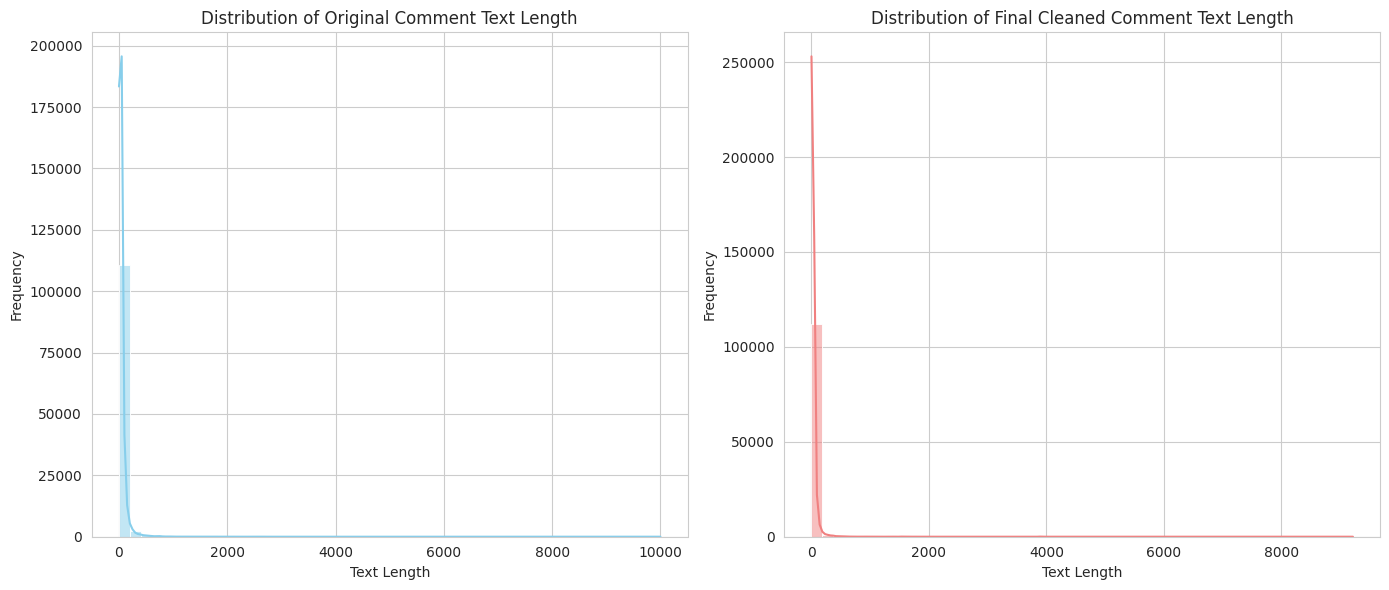

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(14, 6))

# Plot for Original Text Length
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df_cleaned['original_text_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Original Comment Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')

# Plot for Cleaned Text Length
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(df_cleaned['cleaned_text_length'], bins=50, kde=True, color='lightcoral')
plt.title('Distribution of Final Cleaned Comment Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [66]:
# Define the path to save the preprocessed CSV
save_path = '/content/drive/MyDrive/22CDS0446_NLP/preprocessed.csv'

# Save the df_cleaned DataFrame to a CSV file
df_cleaned.to_csv(save_path, index=False)

print(f"Cleaned data saved successfully to {save_path}")

Cleaned data saved successfully to /content/drive/MyDrive/22CDS0446_NLP/preprocessed.csv
